In [ ]:
from pathlib import Path
import geopandas as gpd 
import matplotlib.pyplot as plt 

In [2]:
current_directory = Path.cwd()

In [ ]:
#Define of project paths 

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_directory = project_root/"data"/"raw"
processed_data_directory = project_root/"data"/"processed"
figures_directory = project_root/"ouputs"/"figures"
   

In [6]:
#Loading spatial data

boundary_file =(raw_data_directory/"greater_accra_boundary.geojson")
station_file = (processed_data_directory/"verified_swap_station_points.geojson")

study_boundary = gpd.read_file(boundary_file)
station_gdf = gpd.read_file(station_file)

In [ ]:
#estimating suitbale metre-based crs(coordinate refernce system )
metric_crs = study_boundary.estimate_utm_crs()

print(metric_crs)

EPSG:32631


In [9]:
#Projecting datasets metre

study_boundary_projected = (study_boundary.to_crs(metric_crs))
stations_projected = (station_gdf.to_crs(metric_crs))

In [10]:
print(study_boundary_projected)
print(stations_projected)

   bbox_west  bbox_south  bbox_east  bbox_north  place_id  osm_type   osm_id  \
0  -0.519705    5.470652   0.672259    6.107615  40402087  relation  1991849   

        lat       lon     class            type  place_rank  importance  \
0  5.810153  0.099524  boundary  administrative           8    0.500795   

  addresstype                  name                 display_name  \
0       state  Greater Accra Region  Greater Accra Region, Ghana   

                                            geometry  
0  POLYGON ((110026.821 631288.431, 110109.332 63...  
  analysis_id source_station_id station_area                landmark  \
0      PUB001       Station 002    Abelemkpe     Near Pan African TV   
1      PUB002       Station 003       Adenta            Housing Down   
2      PUB003       Station 004     Kaneshie           Near Vitamilk   
3      PUB004       Station 005   Kokomlemle         Opposite Auto Z   
4      PUB005       Station 006      Spintex        Adjacent Ecobank   
5      PU

In [ ]:
#Validating if the datasets of the projected is equal
print("Are same:", stations_projected.crs == study_boundary_projected.crs)

Are same: True


In [13]:
#Checking differnence between projected and actual

print("Before Projection:")
print(station_gdf.geometry.head(3))

print("\n After Projection:")
print(stations_projected.geometry.head(3))

Before Projection:
0    POINT (-0.22053 5.61314)
1    POINT (-0.15099 5.70882)
2    POINT (-0.23944 5.57067)
Name: geometry, dtype: geometry

 After Projection:
0    POINT (143157.227 621422.112)
1    POINT (150927.924 631972.819)
2    POINT (141033.083 616731.371)
Name: geometry, dtype: geometry


Create 3 km station buffers - Each station recives 3km /3,000 metre buffer representing the intial straight line coverage area .

In [14]:
coverage_radius_metre = 3_000

In [ ]:
#creating buffer geodataframe

coverage_buffers = stations_projected.copy()
coverage_buffers['geometry'] = (stations_projected.geometry.buffer(coverage_radius_metre))

In [17]:
#calculating of buffer areas

coverage_buffers["buffer_area_km2"] = (coverage_buffers.geometry.area/ 1_000_000)

In [19]:
coverage_buffers[["station_area","buffer_area_km2"]]

,station_area,buffer_area_km2
0,Abelemkpe,28.228936
1,Adenta,28.228936
2,Kaneshie,28.228936
3,Kokomlemle,28.228936
4,Spintex,28.228936
5,Aviation,28.228936
6,Osu,28.228936
7,Haatso,28.228936


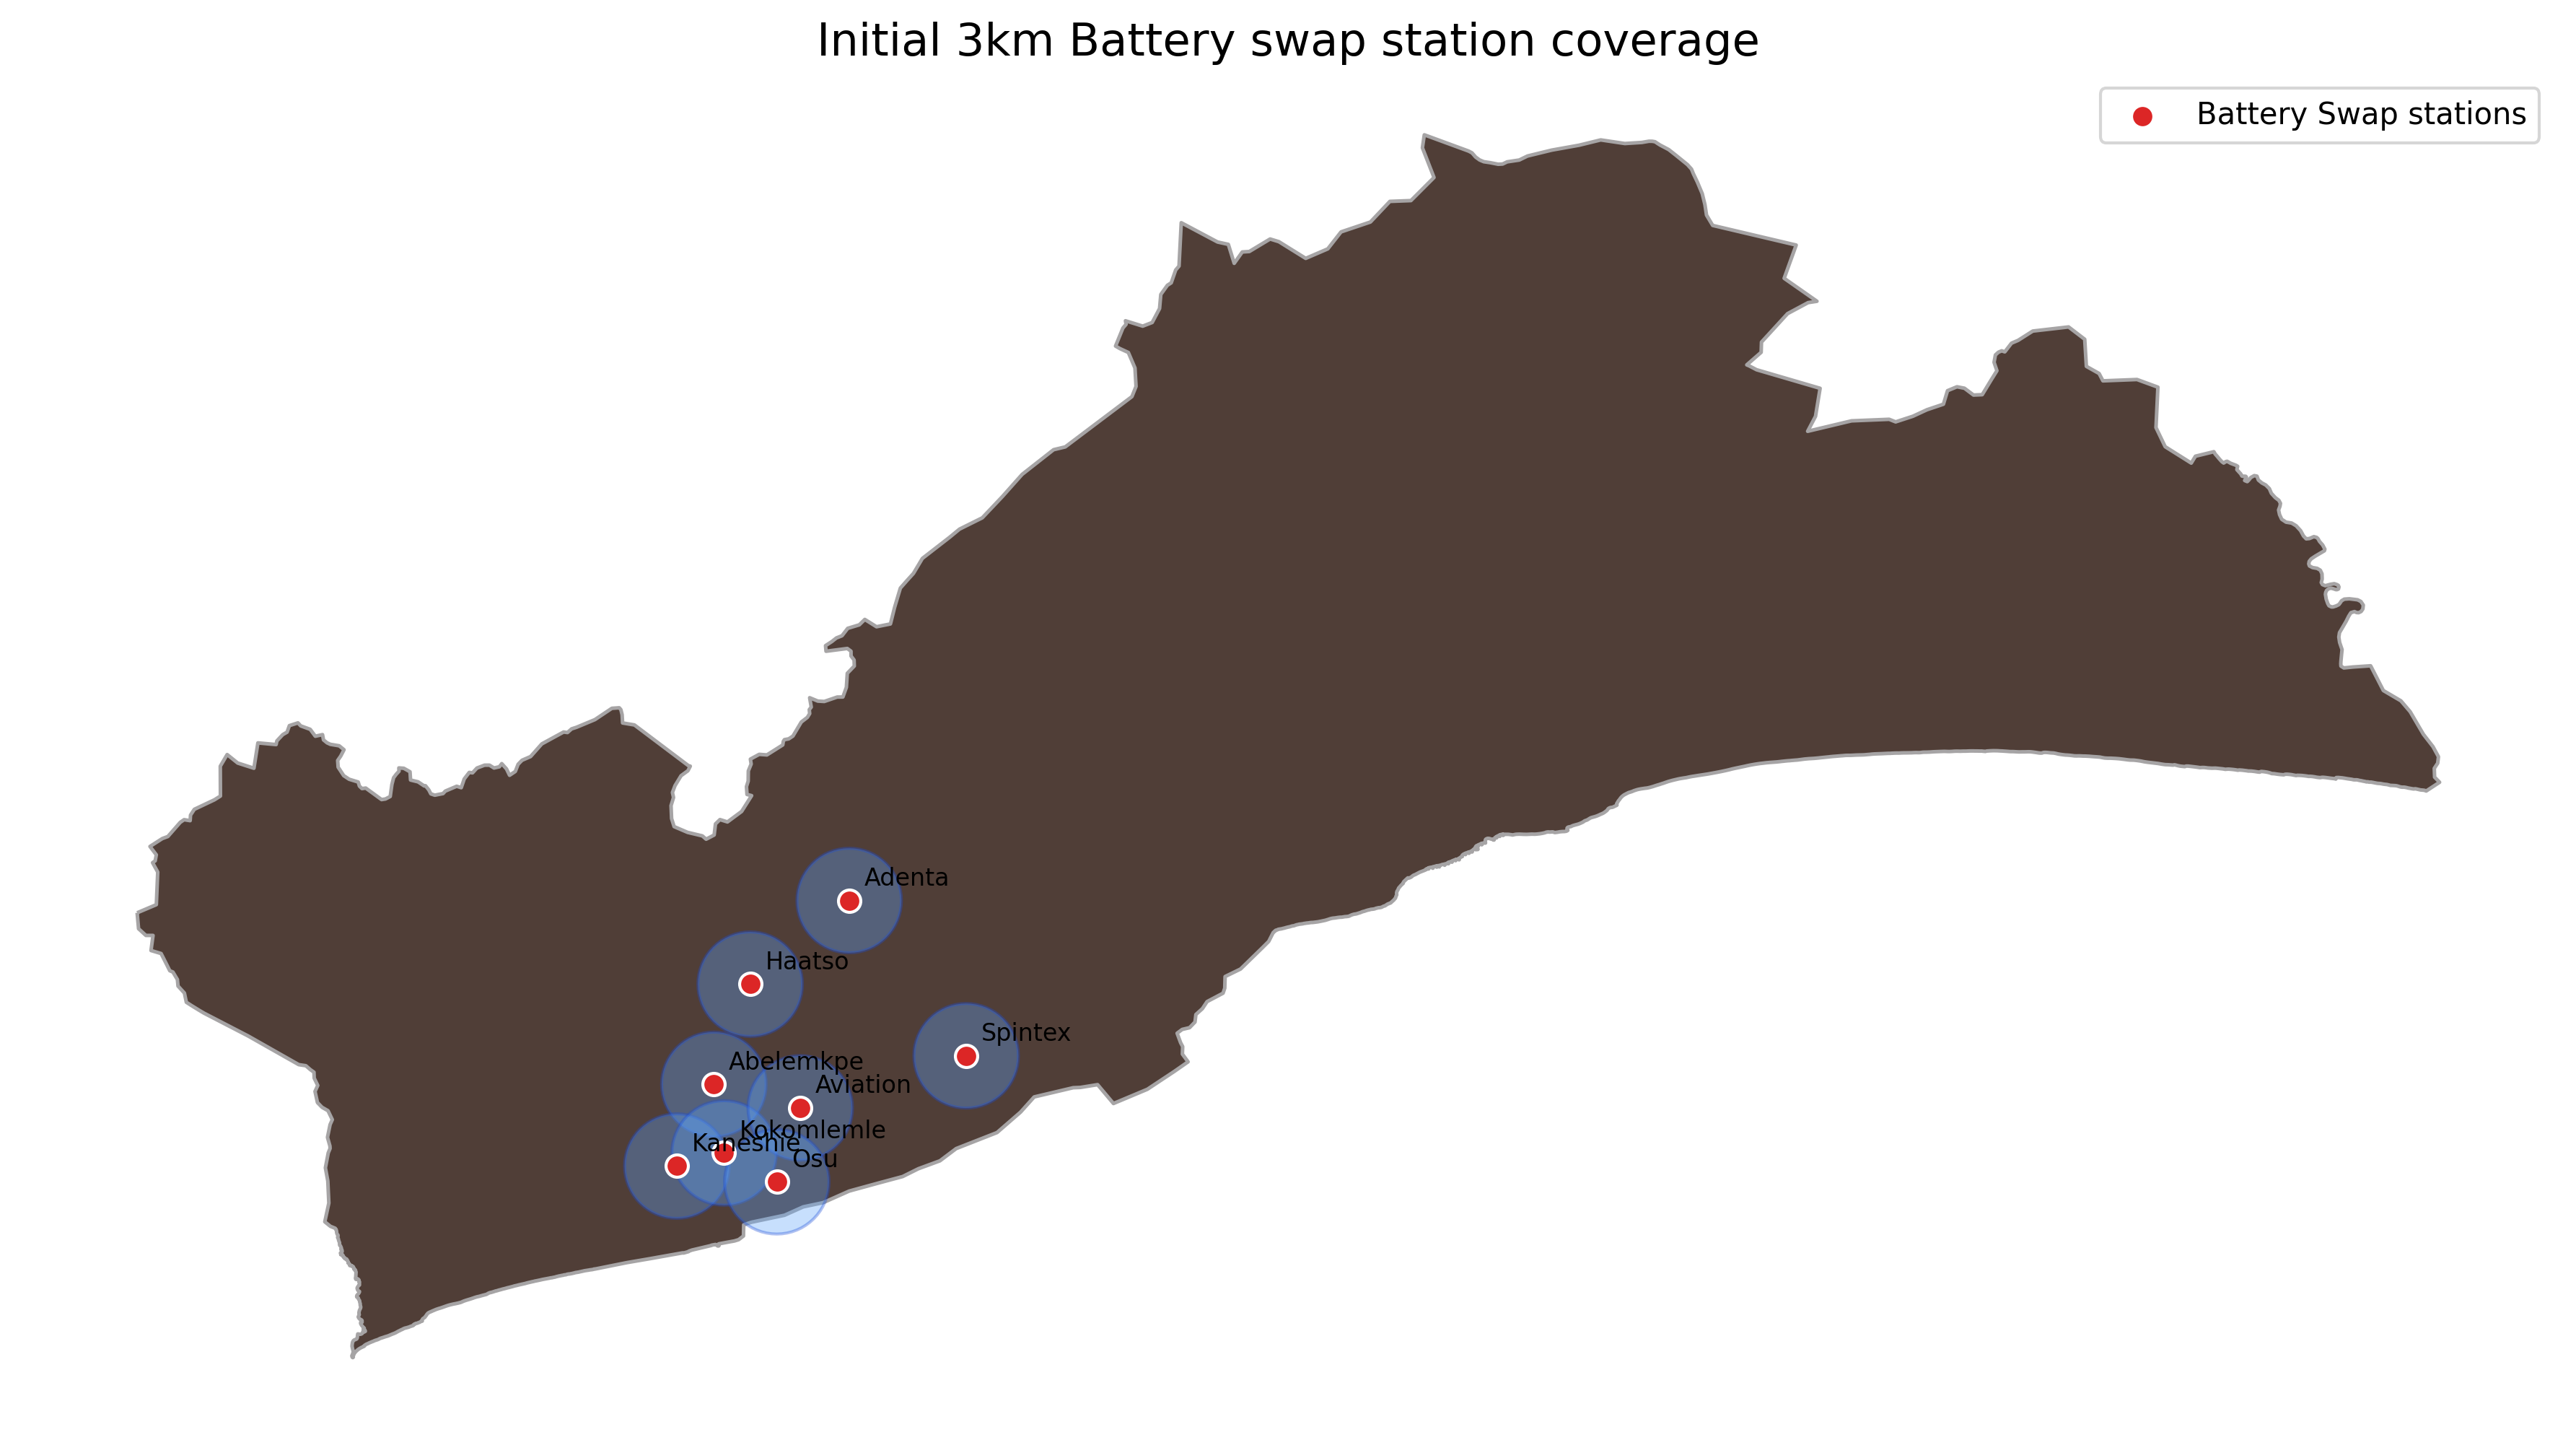

In [24]:
#Plotting of buffers coverage

fig,ax = plt.subplots(figsize=(12,10),dpi=300)
study_boundary_projected.plot( ax=ax,facecolor="#503E37",edgecolor="#a6a4a5",linewidth=1.2,zorder=1,)

coverage_buffers.plot(ax=ax,facecolor="#60a5fa",edgecolor="#1d4ed8",alpha=0.35,linewidth=1,zorder=2,)
stations_projected.plot(ax=ax,color="#dc2626",edgecolor="white",markersize=55,label="Battery Swap stations",zorder=3,)

for _,station in stations_projected.iterrows():
    ax.annotate(text=station["station_area"],xy=(station.geometry.x,station.geometry.y,),
                xytext=(5,5),textcoords="offset points",fontsize=8,zorder=4)
ax.set_title("Initial 3km Battery swap station coverage",fontsize=15,)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

Overlapping station buffers to be merged into a unique coverage footprint.

In [25]:
merged_coverage_geometry = (coverage_buffers.geometry.union_all())

print(merged_coverage_geometry.geom_type,)
print(merged_coverage_geometry.is_valid,)

MultiPolygon
True


In [ ]:
study_boundary_geometry = (study_boundary.geometry.union_all())
study_boundary_geometry

In [28]:
clipped_coverage_geometry = (merged_coverage_geometry.intersection(study_boundary_geometry))

In [29]:
clipped_coverage =gpd.GeoDataFrame(
    { "coverage_radius_km":[coverage_radius_metre/1_000],}, geometry=[clipped_coverage_geometry],crs=metric_crs,
)

In [ ]:
#comparing areas

individual_area_km2 = (coverage_buffers.geometry.area.sum() / 1_0000_000)
merged_area_km2 = (merged_coverage_geometry.area / 1_000_000)
clipped_area_km2 = (clipped_coverage_geometry.area/1_000_000)
overlap_area_km2 = (individual_area_km2 - merged_area_km2)
outside_boundary_area_km2 =(merged_area_km2 - clipped_area_km2)

In [33]:
print("sum of individual buffers:",round(individual_area_km2,2))
print("unique merged coverage:",round(merged_area_km2,2))
print("overlapping boundary:",round(overlap_area_km2,2))
print("coverage inside boundary:",round(clipped_area_km2,2))
print("coverage outside boundary:",round(outside_boundary_area_km2,2))

sum of individual buffers: 22.58
unique merged coverage: 191.67
overlapping boundary: -169.08
coverage inside boundary: 0.0
coverage outside boundary: 191.67


/Users/manafosman/Documents/my_documents/My_Projects/Data_Science /accra-ev-swap-coverage-analysis/.venv/lib/python3.9/site-packages/geopandas/plotting.py:968: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


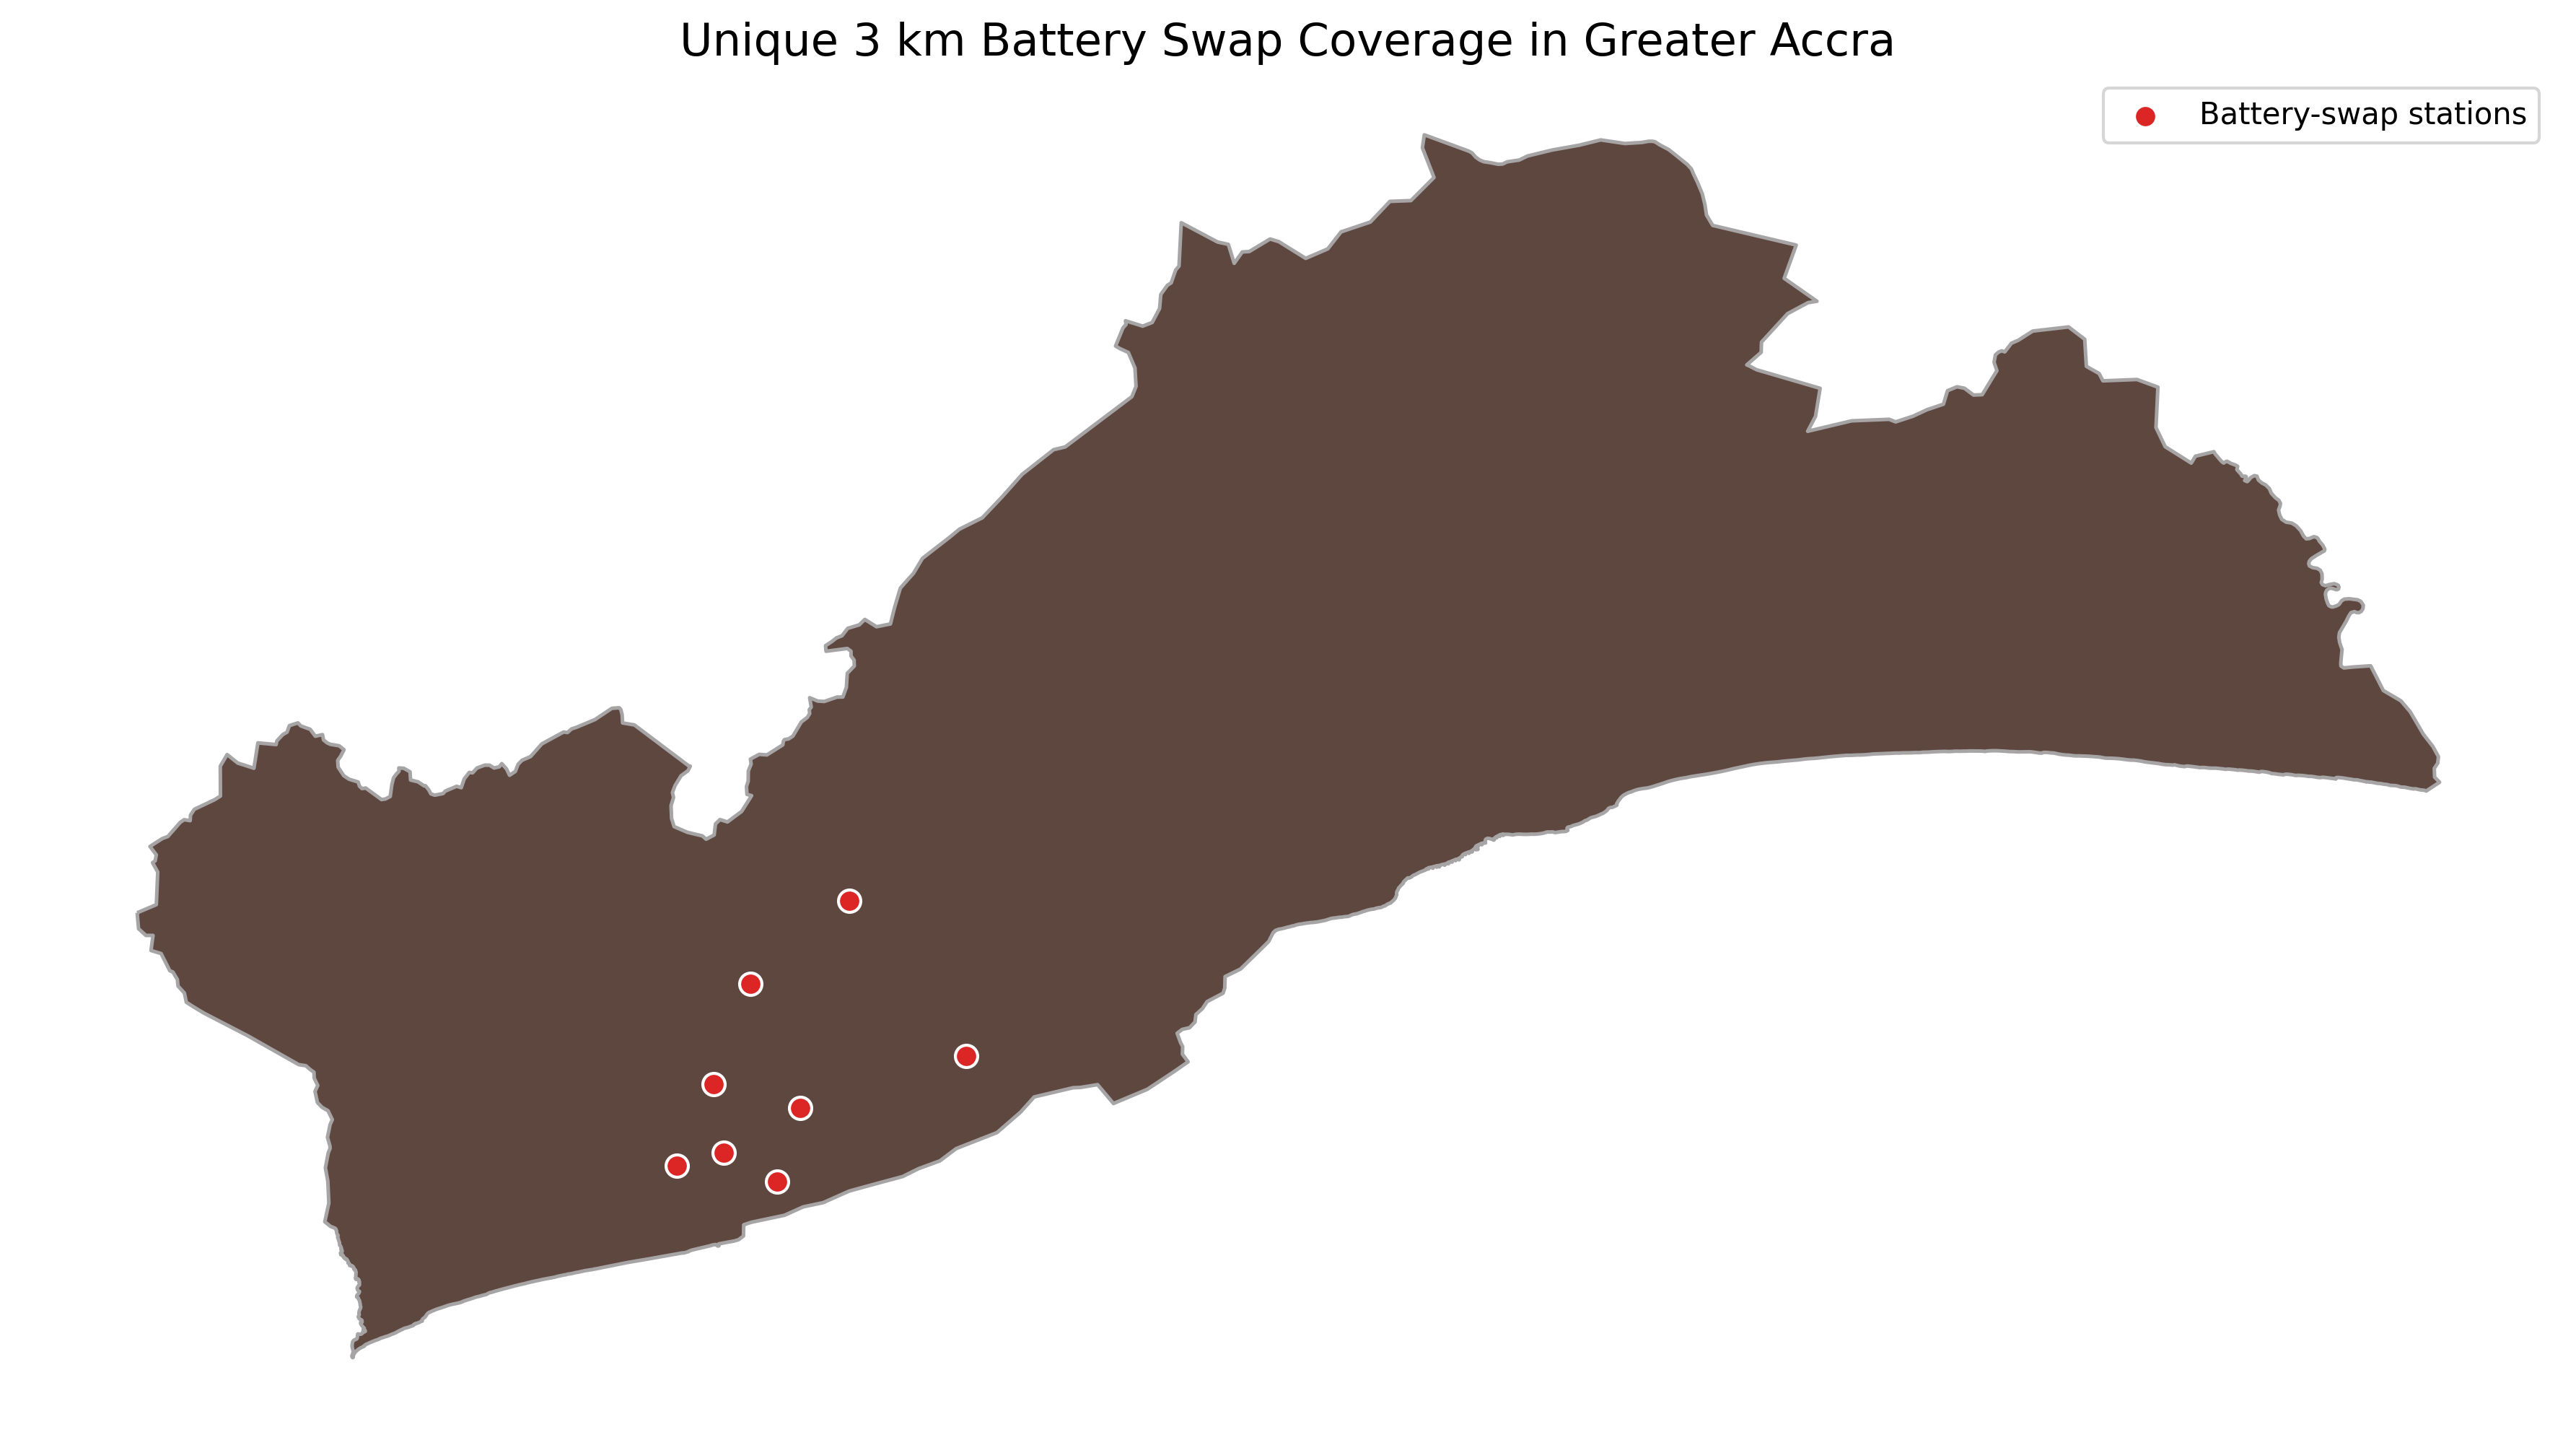

In [39]:
#plot clipping overlapping buffers into one as seen in the map

fig, ax = plt.subplots( figsize=(12, 10),dpi=300,)
study_boundary_projected.plot(ax=ax,facecolor="#5D473F",edgecolor="#a6a4a5",linewidth=1.2,zorder=1,)
clipped_coverage.plot(ax=ax,facecolor="#60a5fa",edgecolor="#1d4ed8",
                      alpha=0.45,linewidth=1,label="Unique 3 km coverage",zorder=2,)
stations_projected.plot(ax=ax,color="#dc2626",edgecolor="white",markersize=55,label="Battery-swap stations",zorder=3,)
ax.set_title("Unique 3 km Battery Swap Coverage in Greater Accra",fontsize=15,)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()